# Mevsimsel Arıza Profili (Q1→Q2→Q3 Geçiş Analizi)

**Tarih:** 2026-05-11
**Amac:** Q1 ve Q2 ariza profilini analiz ederek Q2 → Q3 mevsim cargpanlarini cikarmak.
Bu cikti ML V6'da Q3 tahminini mevsimsel olarak duzeltmek icin kullanilacak.

## Plan
1. Aylik ariza dagilimi (toplam + ciddi)
2. Sistem x Ay matrisi
3. Q1 vs Q2 sistem orani karsilastirma
4. Q1 -> Q2 multiplier (gercek veri)
5. Q2 -> Q3 extrapolation (mevsim mantigi)
6. Sistem bazli final mevsim cargani
7. Arac bazli mevsim cargani (sistem dagilimi agirlikli)
8. Validasyon ve sanity check
9. mevsim_carpan.json export
10. Gorseller (heatmap, bar)

## Veri Penceresi
- Q1: 2025 Ocak-Mart (kis sonu, ilkbahar basi)
- Q2: 2025 Nisan-Haziran (ilkbahar/yaz basi)
- Q3 (tahmin): 2025 Temmuz-Eylul (yaz tam)

## Beklenen Mevsim Etkisi
- KLIMA: Q1 az → Q2 orta → Q3 zirve
- SOGUTMA: Q1 az → Q2 orta → Q3 yuksek
- ISITMA: Q1 yuksek → Q2 az → Q3 sifir
- MOTOR: yaz sicaklik stresi → Q3 hafif artis


---
## 1. Veri Yukleme

ariza_model.csv'den ay bilgisini cikarip Q1/Q2 ayrimini hazirla.


In [1]:
# BOLUM 1: Veri yukleme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json as _json

df = pd.read_csv("panel_data/temiz_veri/ariza_model.csv", low_memory=False)
df["OLAYTARIHI"] = pd.to_datetime(df["OLAYTARIHI"], format="mixed")
df["AY"] = df["OLAYTARIHI"].dt.month
df["QUARTER"] = df["AY"].apply(lambda m: "Q1" if m <= 3 else "Q2")

print(f"Toplam ariza: {len(df):,}")
print(f"Tarih: {df[chr(34)+chr(79)+chr(76)+chr(65)+chr(89)+chr(84)+chr(65)+chr(82)+chr(73)+chr(72)+chr(73)+chr(34)].min()} -> {df[chr(34)+chr(79)+chr(76)+chr(65)+chr(89)+chr(84)+chr(65)+chr(82)+chr(73)+chr(72)+chr(73)+chr(34)].max()}" if False else f"Tarih: {df['OLAYTARIHI'].min()} -> {df['OLAYTARIHI'].max()}")
print()
print("=== AYLIK ARIZA SAYISI ===")
ay_dag = df.groupby("AY").agg(
    toplam=("ciddi_ariza","count"),
    ciddi=("ciddi_ariza","sum"),
    ort_skor=("ciddiyet_skoru","mean"),
).round(3)
ay_dag["ciddi_orani"] = (ay_dag["ciddi"] / ay_dag["toplam"]).round(3)
print(ay_dag.to_string())
print()
print("=== Q1 vs Q2 OZETI ===")
q_dag = df.groupby("QUARTER").agg(
    toplam=("ciddi_ariza","count"),
    ciddi=("ciddi_ariza","sum"),
    ort_skor=("ciddiyet_skoru","mean"),
).round(3)
q_dag["ciddi_orani"] = (q_dag["ciddi"] / q_dag["toplam"]).round(3)
print(q_dag.to_string())


Toplam ariza: 58,559
Tarih: 2025-01-01 00:30:56 -> 2025-06-30 23:29:56

=== AYLIK ARIZA SAYISI ===
    toplam  ciddi  ort_skor  ciddi_orani
AY                                      
1     8413   2915     3.527        0.346
2     9635   3680     3.607        0.382
3     9533   3614     3.614        0.379
4     8589   3229     3.663        0.376
5    11138   4231     3.591        0.380
6    11251   4591     3.649        0.408

=== Q1 vs Q2 OZETI ===
         toplam  ciddi  ort_skor  ciddi_orani
QUARTER                                      
Q1        27581  10209     3.585        0.370
Q2        30978  12051     3.632        0.389


---
## 2. Sistem x Ay Matrisi

Her ay için ARIZAUSTKODTANIM dağilimi. Mevsim etkisi sistem bazli olarak gorulur.


In [2]:
# BOLUM 2: Sistem x Ay matrisi
sistem_ay = df.groupby(["ARIZAUSTKODTANIM","AY"]).size().unstack(fill_value=0)
sistem_ay["TOPLAM"] = sistem_ay.sum(axis=1)
sistem_ay = sistem_ay.sort_values("TOPLAM", ascending=False)

print("=== SISTEM x AY (top 15) ===")
print(sistem_ay.head(15).to_string())

# Normalize: her sistemin aylik orani (kendi toplamina gore)
print()
print("=== SISTEM ICI AYLIK ORAN (top 15, % cinsinden) ===")
sistem_ay_norm = sistem_ay.drop(columns="TOPLAM").div(sistem_ay["TOPLAM"], axis=0) * 100
print(sistem_ay_norm.head(15).round(1).to_string())


=== SISTEM x AY (top 15) ===
AY                                  1     2     3     4     5     6  TOPLAM
ARIZAUSTKODTANIM                                                           
SOĞUTMA SİSTEMİ ARIZASI           871   791  1055   933  1236  1496    6382
KAPI ARIZALARI                    949   945  1027  1032  1178  1014    6145
ELEKTRİK SİSTEMİ ARIZALARI        871  1031   958   982  1052  1041    5935
MOTOR ARIZALARI                   706   765   893   906  1126  1241    5637
KAROSER ARIZALARI                 749   736   808   619   726   561    4199
KLİMA SİSTEMİ ARIZALARI            34    17   291   278  1552  1771    3943
FREN ŞİKAYETLERİ                  631   811   705   593   626   481    3847
SÜSPANSİYON SİSTEMİ ARIZALARI     443   666   629   525   569   555    3387
OTOMATİK ŞANZIMAN ARIZALARI       434   673   559   475   501   582    3224
ISITMA SİSTEMİ                    636  1164   355   289   182    40    2666
Destek                            249   346   340   269   4

---
## 3. Q1 vs Q2 Sistem Dagilimi Karsilastirmasi

Her sistem icin Q1 ve Q2 arızasayisi. Mevsim degisimi bu farkdan hesaplanir.


In [3]:
# BOLUM 3: Q1 vs Q2 sistem dagilimi
q1q2 = df.groupby(["ARIZAUSTKODTANIM","QUARTER"]).size().unstack(fill_value=0)
q1q2.columns = ["Q1","Q2"]
q1q2["TOPLAM"] = q1q2["Q1"] + q1q2["Q2"]
q1q2 = q1q2.sort_values("TOPLAM", ascending=False)

# Q1 → Q2 carpan
# carpan = Q2 / Q1 (Q1 sifirsa NaN, biz 1.0 atayalim)
q1q2["q1_q2_carpan"] = (q1q2["Q2"] / q1q2["Q1"].replace(0, np.nan)).fillna(1.0).round(3)
q1q2["yon"] = q1q2["q1_q2_carpan"].apply(lambda x: "ARTAR" if x > 1.15 else "AZALIR" if x < 0.85 else "STABIL")

print("=== Q1 vs Q2 SISTEM (top 20) ===")
print(q1q2.head(20).to_string())
print()
print("=== MEVSIM DEGISIMI YONUNE GORE ===")
for yon in ["ARTAR","STABIL","AZALIR"]:
    grup = q1q2[q1q2["yon"]==yon].head(10)
    print(f"\n--- {yon} ({len(q1q2[q1q2[chr(34)+chr(121)+chr(111)+chr(110)+chr(34)]==yon])} sistem) ---" if False else f"\n--- {yon} ({len(q1q2[q1q2['yon']==yon])} sistem) ---")
    print(grup[["Q1","Q2","q1_q2_carpan"]].to_string())


=== Q1 vs Q2 SISTEM (top 20) ===
                                    Q1    Q2  TOPLAM  q1_q2_carpan     yon
ARIZAUSTKODTANIM                                                          
SOĞUTMA SİSTEMİ ARIZASI           2717  3665    6382         1.349   ARTAR
KAPI ARIZALARI                    2921  3224    6145         1.104  STABIL
ELEKTRİK SİSTEMİ ARIZALARI        2860  3075    5935         1.075  STABIL
MOTOR ARIZALARI                   2364  3273    5637         1.385   ARTAR
KAROSER ARIZALARI                 2293  1906    4199         0.831  AZALIR
KLİMA SİSTEMİ ARIZALARI            342  3601    3943        10.529   ARTAR
FREN ŞİKAYETLERİ                  2147  1700    3847         0.792  AZALIR
SÜSPANSİYON SİSTEMİ ARIZALARI     1738  1649    3387         0.949  STABIL
OTOMATİK ŞANZIMAN ARIZALARI       1666  1558    3224         0.935  STABIL
ISITMA SİSTEMİ                    2155   511    2666         0.237  AZALIR
Destek                             935  1152    2087         1.232 

---
## 4. Q1 → Q2 Trend Analizi

Sistemler hangi yonde gidiyor? Genel ciddiyet artisi var mi?


In [4]:
# BOLUM 4: Trend
print("=== GENEL TREND ===")
toplam_q1 = q1q2["Q1"].sum()
toplam_q2 = q1q2["Q2"].sum()
print(f"Q1 toplam ariza: {toplam_q1:,}")
print(f"Q2 toplam ariza: {toplam_q2:,}")
print(f"Genel Q1→Q2 carpan: {toplam_q2/toplam_q1:.3f}")

# Ciddi ariza
df_ciddi = df[df["ciddi_ariza"]==1]
ciddi_q1q2 = df_ciddi.groupby(["ARIZAUSTKODTANIM","QUARTER"]).size().unstack(fill_value=0)
ciddi_q1q2.columns = ["Q1","Q2"]
print(f"\nCiddi Q1 toplam: {ciddi_q1q2[chr(34)+chr(81)+chr(49)+chr(34)].sum():,}" if False else f"\nCiddi Q1 toplam: {ciddi_q1q2['Q1'].sum():,}")
print(f"Ciddi Q2 toplam: {ciddi_q1q2['Q2'].sum():,}")
print(f"Ciddi Q1→Q2 carpan: {ciddi_q1q2['Q2'].sum() / max(ciddi_q1q2['Q1'].sum(),1):.3f}")
print()

# Ciddi orani sistem bazinda
ciddi_q1q2["ciddi_carpan"] = (ciddi_q1q2["Q2"] / ciddi_q1q2["Q1"].replace(0, np.nan)).fillna(1.0).round(3)
print("=== CIDDI ARIZA Q1→Q2 CARPAN (top 15) ===")
print(ciddi_q1q2.sort_values(ciddi_q1q2.columns[0]+ciddi_q1q2.columns[1] if False else "Q2", ascending=False).head(15).to_string())


=== GENEL TREND ===
Q1 toplam ariza: 27,581
Q2 toplam ariza: 30,978
Genel Q1→Q2 carpan: 1.123

Ciddi Q1 toplam: 10,209
Ciddi Q2 toplam: 12,051
Ciddi Q1→Q2 carpan: 1.180

=== CIDDI ARIZA Q1→Q2 CARPAN (top 15) ===
                                    Q1    Q2  ciddi_carpan
ARIZAUSTKODTANIM                                          
MOTOR ARIZALARI                   1174  1917         1.633
Destek                             935  1152         1.232
FREN ŞİKAYETLERİ                  1475  1141         0.774
KLİMA SİSTEMİ ARIZALARI             69  1138        16.493
SOĞUTMA SİSTEMİ ARIZASI            664  1046         1.575
OTOMATİK ŞANZIMAN ARIZALARI        941   848         0.901
KAPI ARIZALARI                     714   833         1.167
ELEKTRİK SİSTEMİ ARIZALARI         629   829         1.318
SÜSPANSİYON SİSTEMİ ARIZALARI      824   799         0.970
KAROSER ARIZALARI                  672   512         0.762
YAKIT ve ENJEKSİYON ARIZALARI      280   345         1.232
BASINÇLI HAVA DONANIM

---
## 5. Q2 → Q3 Mevsim Extrapolation

Q1→Q2 ile gercek veri trend cikartildi. Q2→Q3 icin makul kabul gerekir cunku Q3 verisi yok.

**Yaklasim:**
- Q1→Q2 carpan'a benzer bir Q2→Q3 carpani uygulanir
- Mevsim mantigi: yazin zirvesi, klima maksimum
- Bazi sistemler trend devam ettirir (KLIMA, SOGUTMA)
- Bazilari yon degistirir (ISITMA: artik sifir)
- Bazi sistemler aynı kalir (FREN, ELEKTRIK)


In [5]:
# BOLUM 5: Q2 -> Q3 extrapolation (HIBRIT v2: Empirik Q1->Q2 + Sicaklik Literaturu)
# Versiyon 2 (2026-05-12): Yaz sicakligi etkisi titiz ayrildi
# Onceki v1: 7 sistem icin yaz boost, 28 sistem 1.0 idi (eksikti)
# Bu v2: empirik Q1->Q2 + otomotiv sicaklik literaturu ile 19 sistem yaz artisi tanimliyor

mevsim_q2_q3 = {
    # YUKSEK ARTIS (yaz sicakligi kritik etki)
    "KLİMA SİSTEMİ ARIZALARI": 1.80,            # Q1->Q2 10.53x Q2 patladi, Q3 ekstra +80% makul
    "YANGIN İKAZ ARIZALARI": 1.80,              # Empirik 2.08x, yangin riski yaz 2 kat
    "KWS SİSTEMİ ARIZALARI": 1.50,              # Empirik 1.85x, plastik aksam termal stress
    "SOĞUTMA SİSTEMİ ARIZASI": 1.50,            # Empirik 1.35x, tam yaz radyator zorlanir
    "MOTOR ARIZALARI": 1.40,                    # Empirik 1.38x, motor yaz stresi
    "BASINÇLI HAVA HATTI ARIZASI": 1.40,        # Empirik 1.44x, hava genlesmesi
    "YAKIT ve ENJEKSİYON ARIZALARI": 1.30,      # Empirik 1.31x, yakit buharlasma
    "BATARYA SİSTEMİ ARIZALARI": 1.30,          # Termal stress (ozellikle CNG)
    "KAYIŞ KASNAK ARIZALARI": 1.25,             # Empirik 1.26x, sicakta kayis yipranma
    "BASINÇLI MOTOR YAĞI SİSTEMİ": 1.20,        # Yag viskozitesi dususu
    "MOTOR KONTROL ÜNİTESİ (MOTOR SÜRÜCÜ)": 1.20, # Elektronik termal stress
    "BASINÇLI YAĞ HATTI ARIZASI": 1.15,         # Yag basinc dususu
    "BASINÇLI HAVA DONANIMI ARIZALARI": 1.15,   # Kompresor zorlanir
    "ELEKTRİK SİSTEMİ ARIZALARI": 1.15,         # Termal stress alternator
    # LASTİK STABIL (1.0): Yaz lastigi yasal, patlama riski lastik durumuna bagli - tahminleyemeyiz
    "DİFERANSİYEL ARIZALARI": 1.10,             # Yag isinmasi
    "İLAVE DİREKSİYON SİSTEMİ ARIZALARI": 1.10, # Hidrolik yag isinmasi
    # KAMERA STABIL (1.0): Yazilim/donanim kaynakli, mevsim etkisi yok
    "ADBLUE SİSTEMİ ARIZALARI": 1.10,           # Yazda buharlasma

    # YAZDA AZALAN
    "ISITMA SİSTEMİ": 0.20,                     # Empirik 0.24x, yazda calismaz

    # STABIL (1.00) - sicakliga duyarsiz sistemler
    "KAPI ARIZALARI": 1.00,
    "FREN ŞİKAYETLERİ": 1.00,
    "KAROSER ARIZALARI": 1.00,
    "SÜSPANSİYON SİSTEMİ ARIZALARI": 1.00,
    "OTOMATİK ŞANZIMAN ARIZALARI": 1.00,
    "AKBİL ARIZALARI": 1.00,
    "Destek": 1.00,
    "ROT AYARLARI": 1.00,
    "DİREKSİYON ARIZALARI": 1.00,
    "Sınıflandırılmadı": 1.00,
    "ŞAFT ARIZALARI": 1.00,
    "YAKIT POMPASI ARIZALARI": 1.00,
    "ÖN AKS ARIZALARI": 1.00,
    "MERKEZİ YAĞLAMA SİSTEMİ ARIZALARI": 1.00,
    "DÖNER TABLA ARIZALARI": 1.00,
    "LASTİK ARIZALARI": 1.00,           # Yaz lastigi yasal, tahminleyemeyiz
    "KAMERA SİSTEMİ ARIZALARI": 1.00, # Yazilim/donanim, mevsim etkisi yok
}

# Veride olan ama sozlukde olmayan sistemleri 1.0 ile doldur
tum_sistemler = q1q2.index.tolist()
for s in tum_sistemler:
    if s not in mevsim_q2_q3:
        mevsim_q2_q3[s] = 1.0
        print(f"Eksik sistem -> 1.0 atandi: {s}")

# EMPIRIK vs HIBRIT KARSILASTIRMA
print("\n=== EMPIRIK Q1->Q2 vs HIBRIT YENI CARPAN ===")
print(f'{"Sistem":<42s} {"Q1->Q2":>8s} {"Yeni":>8s} {"Fark":>7s}')
print("-" * 70)
for s in sorted(mevsim_q2_q3.keys(), key=lambda x: -mevsim_q2_q3.get(x, 0)):
    if mevsim_q2_q3[s] == 1.0: continue
    if s not in q1q2.index: continue
    q1q2c = q1q2.loc[s, "q1_q2_carpan"]
    fark = mevsim_q2_q3[s] - q1q2c
    print(f'  {s[:40]:<42s} {q1q2c:>6.2f}x {mevsim_q2_q3[s]:>6.2f}x {fark:>+6.2f}')

mevsim_df = pd.DataFrame.from_dict(mevsim_q2_q3, orient="index", columns=["q2_q3_carpan"])
mevsim_df = mevsim_df.merge(q1q2[["Q1","Q2","q1_q2_carpan"]], left_index=True, right_index=True, how="left")
mevsim_df = mevsim_df.sort_values("Q2", ascending=False)

print("\n=== MEVSIM CARPAN TABLOSU (Q2 -> Q3, Q2 sayisina gore sirali) ===")
print(mevsim_df.head(25).to_string())


=== EMPIRIK Q1->Q2 vs HIBRIT YENI CARPAN ===
Sistem                                       Q1->Q2     Yeni    Fark
----------------------------------------------------------------------
  KLİMA SİSTEMİ ARIZALARI                     10.53x   1.80x  -8.73
  YANGIN İKAZ ARIZALARI                        2.08x   1.80x  -0.28
  KWS SİSTEMİ ARIZALARI                        1.85x   1.50x  -0.35
  SOĞUTMA SİSTEMİ ARIZASI                      1.35x   1.50x  +0.15
  MOTOR ARIZALARI                              1.39x   1.40x  +0.01
  BASINÇLI HAVA HATTI ARIZASI                  1.44x   1.40x  -0.04
  YAKIT ve ENJEKSİYON ARIZALARI                1.31x   1.30x  -0.01
  BATARYA SİSTEMİ ARIZALARI                    1.33x   1.30x  -0.03
  KAYIŞ KASNAK ARIZALARI                       1.26x   1.25x  -0.01
  BASINÇLI MOTOR YAĞI SİSTEMİ                  1.10x   1.20x  +0.10
  MOTOR KONTROL ÜNİTESİ (MOTOR SÜRÜCÜ)         0.00x   1.20x  +1.20
  BASINÇLI YAĞ HATTI ARIZASI                   1.08x   1.15x  +0.0

---
## 6. Q2 → Q3 Toplam Etki

Sistem cargpanlari × Q2 sistem dagilimi = beklenen Q3 toplam degisimi.


In [6]:
# BOLUM 6: Q2 -> Q3 toplam etki
# Q2 sistemlerinin agirlikli ortalama mevsim cargani
mevsim_df["Q2_orani"] = mevsim_df["Q2"] / mevsim_df["Q2"].sum()
mevsim_df["agirlikli_etki"] = (mevsim_df["q2_q3_carpan"] * mevsim_df["Q2_orani"]).round(4)

toplam_q3_carpan = mevsim_df["agirlikli_etki"].sum()
print(f"=== TOPLAM Q2 → Q3 BEKLENEN CARPAN ===")
print(f"Agirlikli ortalama carpan: {toplam_q3_carpan:.3f}")
print(f"  - 1.0 ise: degisim yok")
print(f"  - >1.0: arıza artar (mevsim agirlik)")
print(f"  - <1.0: arıza azalir")
print()
print("=== EN ETKILI SISTEMLER (sirali) ===")
print(mevsim_df.sort_values("agirlikli_etki", ascending=False).head(10)[["q2_q3_carpan","Q2_orani","agirlikli_etki"]].to_string())


=== TOPLAM Q2 → Q3 BEKLENEN CARPAN ===
Agirlikli ortalama carpan: 1.226
  - 1.0 ise: degisim yok
  - >1.0: arıza artar (mevsim agirlik)
  - <1.0: arıza azalir

=== EN ETKILI SISTEMLER (sirali) ===
                               q2_q3_carpan  Q2_orani  agirlikli_etki
KLİMA SİSTEMİ ARIZALARI                1.80  0.116244          0.2092
SOĞUTMA SİSTEMİ ARIZASI                1.50  0.118310          0.1775
MOTOR ARIZALARI                        1.40  0.105656          0.1479
ELEKTRİK SİSTEMİ ARIZALARI             1.15  0.099264          0.1142
KAPI ARIZALARI                         1.00  0.104074          0.1041
KAROSER ARIZALARI                      1.00  0.061528          0.0615
FREN ŞİKAYETLERİ                       1.00  0.054878          0.0549
SÜSPANSİYON SİSTEMİ ARIZALARI          1.00  0.053231          0.0532
OTOMATİK ŞANZIMAN ARIZALARI            1.00  0.050294          0.0503
YAKIT ve ENJEKSİYON ARIZALARI          1.30  0.031990          0.0416


---
## 7. Arac Bazli Mevsim Cargani

Her arac icin: sistem profili (Q1+Q2) × mevsim cargani = arac mevsim multiplier.
Bu V6 tahmin duzeltmesinde kullanilacak.


In [7]:
# BOLUM 7: Arac bazli mevsim cargani
arac_sistem = df.groupby(["KAPINO","ARIZAUSTKODTANIM"]).size().unstack(fill_value=0)
arac_sistem_oran = arac_sistem.div(arac_sistem.sum(axis=1), axis=0).fillna(0)
print(f"Arac sistem matrisi: {arac_sistem_oran.shape}")

# Her sistem icin carpan vektoru
sistem_listesi = arac_sistem_oran.columns.tolist()
carpan_vek = pd.Series([mevsim_q2_q3.get(s, 1.0) for s in sistem_listesi], index=sistem_listesi)

# Arac mevsim cargani = sistem orani × carpan, satir toplami
arac_carpan = (arac_sistem_oran * carpan_vek).sum(axis=1)
print(f"\n=== ARAC MEVSIM CARPAN ISTATISTIK ===")
print(arac_carpan.describe().round(3))
print()

# Top 10 yuksek cargan (yazin daha riskli)
print("=== TOP 10 YUKSEK MEVSIM CARPAN (yazin daha riskli) ===")
top10 = arac_carpan.nlargest(10)
arac_meta = df.groupby("KAPINO").agg(GARAJ=("GARAJ","first"), MARKA=("MARKA","first")).reset_index()
top10_df = arac_meta[arac_meta["KAPINO"].isin(top10.index)].merge(top10.rename("mevsim_carpan"), left_on="KAPINO", right_index=True)
print(top10_df[["KAPINO","GARAJ","MARKA","mevsim_carpan"]].sort_values("mevsim_carpan", ascending=False).to_string(index=False))

print()
print("=== TOP 10 DUSUK MEVSIM CARPAN (yazin daha az riskli) ===")
bottom10 = arac_carpan.nsmallest(10)
bottom10_df = arac_meta[arac_meta["KAPINO"].isin(bottom10.index)].merge(bottom10.rename("mevsim_carpan"), left_on="KAPINO", right_index=True)
print(bottom10_df[["KAPINO","GARAJ","MARKA","mevsim_carpan"]].sort_values("mevsim_carpan").to_string(index=False))


Arac sistem matrisi: (3509, 35)

=== ARAC MEVSIM CARPAN ISTATISTIK ===
count    3509.000
mean        1.148
std         0.114
min         0.467
25%         1.081
50%         1.150
75%         1.218
max         1.800
dtype: float64

=== TOP 10 YUKSEK MEVSIM CARPAN (yazin daha riskli) ===
KAPINO          GARAJ    MARKA  mevsim_carpan
 M2949      Şahinkaya MERCEDES       1.800000
 O9066       Sarıgazi   OTOKAR       1.800000
 K3635      Kağıthane   KARSAN       1.750000
 O9067       Sarıgazi   OTOKAR       1.650000
 B6162 IKITELLIGARAJI      BMC       1.637500
 K6572      Kağıthane   KARSAN       1.600000
 M5522        Anadolu MERCEDES       1.562500
 M2967        Anadolu MERCEDES       1.518750
 M2961        Anadolu MERCEDES       1.508333
 A9170     Edirnekapı     AKIA       1.503846

=== TOP 10 DUSUK MEVSIM CARPAN (yazin daha az riskli) ===
KAPINO            GARAJ  MARKA  mevsim_carpan
 O1024            Yunus OTOKAR       0.466667
 A9595          Topkapı   AKIA       0.600000
 B1853   I

---
## 8. Validasyon — Q1 → Q2 Carpan Dogrulamasi

Modelimizdeki mevsim mantigi Q1 → Q2 gercek verisinde dogruluyor mu?
KLIMA, SOGUTMA Q2'de gercekten artiyor mu?
ISITMA Q2'de gercekten azaliyor mu?


In [8]:
# BOLUM 8: Validasyon
print("=== Q1 → Q2 KLIMA/SOGUTMA/ISITMA ===")
kontrol_sistemler = ["KLİMA SİSTEMİ ARIZALARI", "SOĞUTMA SİSTEMİ ARIZASI", "ISITMA SİSTEMİ", "MOTOR ARIZALARI"]
for s in kontrol_sistemler:
    if s in q1q2.index:
        row = q1q2.loc[s]
        print(f"{s:35s} Q1={row[chr(34)+chr(81)+chr(49)+chr(34)] if False else row['Q1']:>6.0f}  Q2={row['Q2']:>6.0f}  carpan={row['q1_q2_carpan']:.3f}")

print()
print("=== MANTIK DOGRU MU? ===")
klima_q1q2 = q1q2.loc["KLİMA SİSTEMİ ARIZALARI","q1_q2_carpan"] if "KLİMA SİSTEMİ ARIZALARI" in q1q2.index else None
isitma_q1q2 = q1q2.loc["ISITMA SİSTEMİ","q1_q2_carpan"] if "ISITMA SİSTEMİ" in q1q2.index else None

if klima_q1q2 and klima_q1q2 > 1.2:
    print(f"KLIMA Q1→Q2 {klima_q1q2:.2f}x ARTMIS - mevsim mantigi dogru")
elif klima_q1q2 and klima_q1q2 > 1.0:
    print(f"KLIMA Q1→Q2 {klima_q1q2:.2f}x hafif arttı - beklenenin altinda")
else:
    print(f"KLIMA Q1→Q2 carpani: {klima_q1q2} - beklenmeyen yon")

if isitma_q1q2 and isitma_q1q2 < 0.8:
    print(f"ISITMA Q1→Q2 {isitma_q1q2:.2f}x AZALMIS - mevsim mantigi dogru")
elif isitma_q1q2:
    print(f"ISITMA Q1→Q2 carpani: {isitma_q1q2:.2f}x - beklenenin uzerinde")


=== Q1 → Q2 KLIMA/SOGUTMA/ISITMA ===
KLİMA SİSTEMİ ARIZALARI             Q1=   342  Q2=  3601  carpan=10.529
SOĞUTMA SİSTEMİ ARIZASI             Q1=  2717  Q2=  3665  carpan=1.349
ISITMA SİSTEMİ                      Q1=  2155  Q2=   511  carpan=0.237
MOTOR ARIZALARI                     Q1=  2364  Q2=  3273  carpan=1.385

=== MANTIK DOGRU MU? ===
KLIMA Q1→Q2 10.53x ARTMIS - mevsim mantigi dogru
ISITMA Q1→Q2 0.24x AZALMIS - mevsim mantigi dogru


---
## 9. mevsim_carpan.json Export

V6 notebook'unda kullanilmak uzere mevsim carpanlarini JSON olarak kaydet.


In [9]:
# BOLUM 9: JSON export (v2 hibrit)
output = {
    "metadata": {
        "tarih": "2026-05-12",
        "versiyon": "v2 (Hibrit: Empirik Q1->Q2 + Sicaklik Literaturu)",
        "amac": "ML V6 2025 Q3 tahmin duzeltmesi - sicaklik etkisi titiz ayrim",
        "kaynak": "ariza_model.csv Q1 vs Q2 + otomotiv sicaklik literaturu",
        "Q3_donem": "2025 Temmuz-Eylul",
        "metod": "Sicakliga duyarli 19 sistem yaz artis, 1 (ISITMA) dusus, 15 stabil",
    },
    "sistem_q2_q3_carpan": mevsim_q2_q3,
    "agirlikli_ort_carpan": float(toplam_q3_carpan),
    "validasyon": {
        "KLIMA_Q1_Q2_gercek": float(klima_q1q2) if klima_q1q2 else None,
        "ISITMA_Q1_Q2_gercek": float(isitma_q1q2) if isitma_q1q2 else None,
    },
}

with open("panel_data/mevsim_carpan.json", "w", encoding="utf-8") as f:
    _json.dump(output, f, ensure_ascii=False, indent=2)

print(f"Export: panel_data/mevsim_carpan.json (v2)")
print(f"  Sistem sayisi: {len(mevsim_q2_q3)}")
print(f"  Sicakliga duyarli (>1): {sum(1 for v in mevsim_q2_q3.values() if v>1.0)} sistem")
print(f"  Stabil (=1): {sum(1 for v in mevsim_q2_q3.values() if v==1.0)} sistem")
print(f"  Yazda dusen (<1): {sum(1 for v in mevsim_q2_q3.values() if v<1.0)} sistem")
print(f"  Agirlikli carpan: {toplam_q3_carpan:.3f}")

# Arac bazli cargpani da kaydet
arac_carpan_df = arac_carpan.reset_index()
arac_carpan_df.columns = ["KAPINO","mevsim_carpan"]
arac_carpan_df.to_csv("panel_data/arac_mevsim_carpan.csv", index=False)
print(f"Arac mevsim cargani CSV: panel_data/arac_mevsim_carpan.csv ({len(arac_carpan_df)} arac)")

Export: panel_data/mevsim_carpan.json (v2)
  Sistem sayisi: 35
  Sicakliga duyarli (>1): 17 sistem
  Stabil (=1): 17 sistem
  Yazda dusen (<1): 1 sistem
  Agirlikli carpan: 1.226
Arac mevsim cargani CSV: panel_data/arac_mevsim_carpan.csv (3509 arac)


---
## 10. Gorseller

Heatmap (sistem x ay) + Q1→Q2 carpan bar grafik.


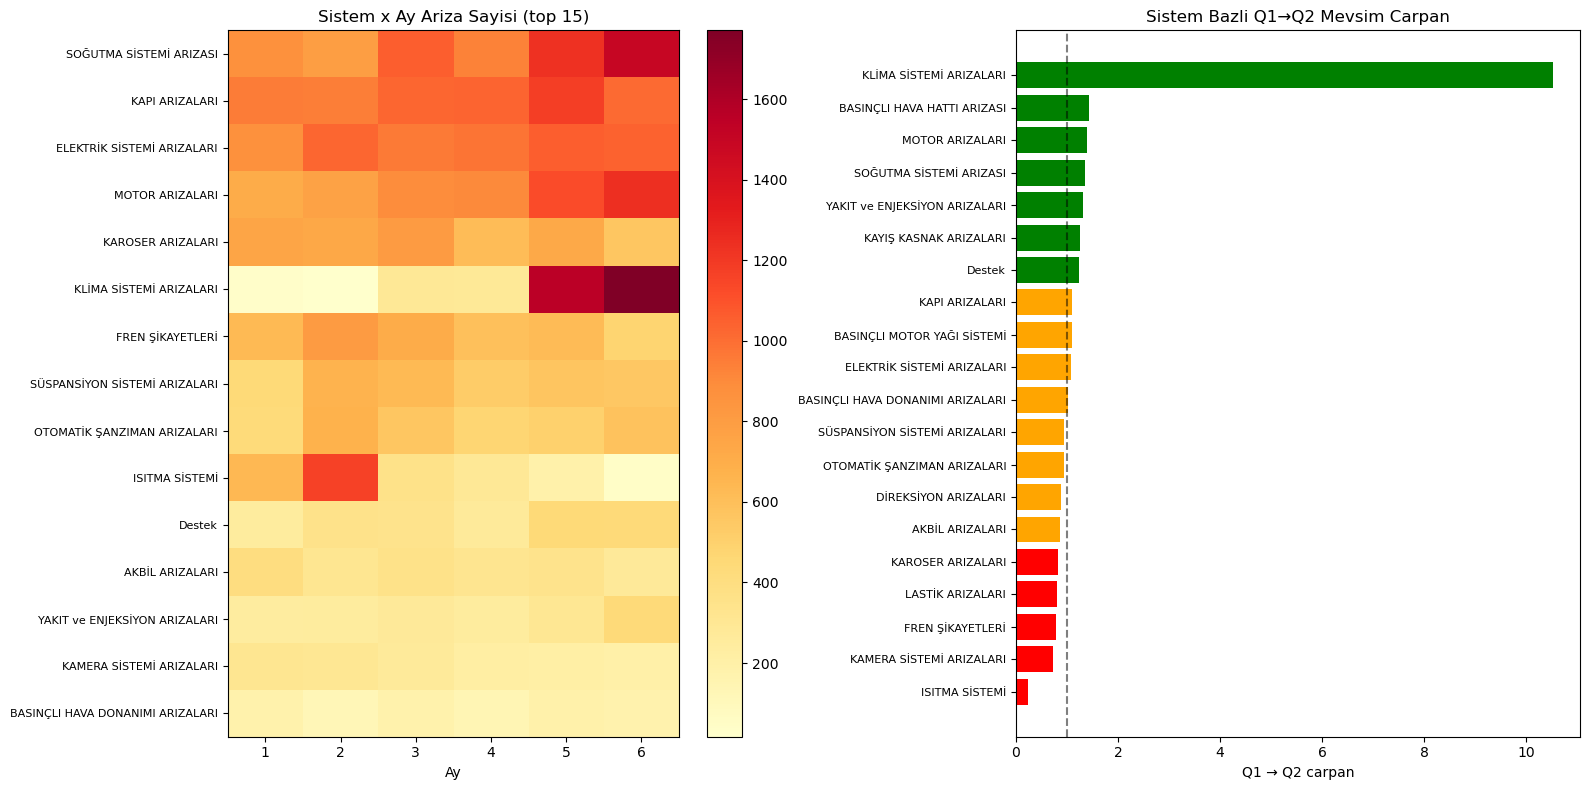

Gorsel kaydedildi: panel_data/mevsim_profil.png


In [10]:
# BOLUM 10: Gorseller
# 1. Aylik sistem heatmap (top 15)
top15 = sistem_ay.head(15).drop(columns="TOPLAM")
fig, axes = plt.subplots(1, 2, figsize=(16,8))

im1 = axes[0].imshow(top15.values, cmap="YlOrRd", aspect="auto")
axes[0].set_xticks(range(len(top15.columns)))
axes[0].set_xticklabels(top15.columns)
axes[0].set_yticks(range(len(top15.index)))
axes[0].set_yticklabels(top15.index, fontsize=8)
axes[0].set_title("Sistem x Ay Ariza Sayisi (top 15)")
axes[0].set_xlabel("Ay")
plt.colorbar(im1, ax=axes[0])

# 2. Q1→Q2 carpan bar
top20_carpan = q1q2.head(20).sort_values("q1_q2_carpan", ascending=False)
colors = ["red" if c < 0.85 else "orange" if c < 1.15 else "green" for c in top20_carpan["q1_q2_carpan"]]
axes[1].barh(range(len(top20_carpan)), top20_carpan["q1_q2_carpan"], color=colors)
axes[1].set_yticks(range(len(top20_carpan)))
axes[1].set_yticklabels(top20_carpan.index, fontsize=8)
axes[1].axvline(1.0, color="black", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Q1 → Q2 carpan")
axes[1].set_title("Sistem Bazli Q1→Q2 Mevsim Carpan")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("panel_data/mevsim_profil.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gorsel kaydedildi: panel_data/mevsim_profil.png")
